In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import autolens as al
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from lenstronomy.Util import param_util
import matplotlib.patches as mpatches

cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)
c=2.998*10**5

%matplotlib inline

2022-02-03 17:17:01,694 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2022-02-03 17:17:01,808 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2022-02-03 17:17:01,908 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


## Parameter conversion:

## PyAutoLens, Lenstronomy $\large \rightarrow$ Lenstool

$\large (x_l, y_l, x_s, y_s, \xi_x, \xi_y, \theta_E) \rightarrow (x_l, y_l, \theta, \epsilon, \sigma_v)$ 

## Einstein Angle:
\begin{align}
\large\theta_E = \frac{4\pi \sigma_v^2}{c^2}\frac{D_A^{(LS)}}{D_A^{(s)}},
\end{align}
where $\large D_A(z) = \frac{1}{1+z}\frac{c}{H_0} \int^z_0 \frac{dz'}{E(z')}$.

Lens to source angular diameter distance:

\begin{align}
\large D_A^{(LS)} = \frac{1}{1+z_s} [D_m(z_s) - D_m(z_l)],
\end{align}

For $\large \Omega_k = 0$.


In [2]:
def convert_radi_sigma(theta_e, z_l, z_s):
    #arcsec to radians factor
    arcsec_to_rad_factor = 4.84814*10**(-6)
    theta_e_rad=np.array(theta_e)*arcsec_to_rad_factor
    # lens to source angular diameter distance
    d_ls=cosmo.angular_diameter_distance_z1z2(z_l, z_s).value
    # source angular diameter distance
    d_s=cosmo.angular_diameter_distance(z_s).value
    # distance fraction
    factor=d_ls/d_s
    # sigma v conversion
    sigma_v = np.sqrt((c**2/(4*np.pi))*theta_e_rad/factor)
    return sigma_v

In [3]:
def convert_ellcomp_exc_ang(ell_comp_0, ell_comp_1):
    ax_ratio = []
    ang = []
    for i in range(0, len(ell_comp_0)):
        ax_ratio_value, ang_value = al.convert.phi_from((ell_comp_0[i], ell_comp_1[i]))
        ax_ratio.append(ax_ratio_value)
        ang.append(ang_value)
    return np.sqrt(1-np.array(ax_ratio)**2), ang # trocar

In [4]:
def convert_ellcomp_exc_ang_lenstool(ell_comp_x, ell_comp_y):
    angle = []
    exc = []
    for i in range(0, len(ell_comp_x)):
        phi, q = param_util.ellipticity2phi_q(ell_comp_x[i], ell_comp_y[i])
        angle.append(np.degrees(phi))
        exc.append(np.sqrt(1-q**2))
    return exc, angle # trocar

In [5]:
# dataframe paths
dataframe_paths = './output_dataframes/'

In [6]:
# loading our dataframes
# Anna's dataframe made using lenstool
"""
lenstool_ds9 = pd.read_csv(dataframe_paths+'lenstool_013639_ds9.dat',
                           sep='\s+',
                           names=['N', 'ln_likelihood', 'x', 'y', 'emass', 'theta', 'sigma', 'chi2'])
lenstool_bary = pd.read_csv(dataframe_paths+'lenstool_013639_bary.dat',
                            sep='\s+',
                            names=['N', 'ln_likelihood', 'x', 'y', 'emass', 'theta', 'sigma', 'chi2'])
lenstool_peak = pd.read_csv(dataframe_paths+'lenstool_013639_peak.dat',
                            sep='\s+',
                            names=['N', 'ln_likelihood', 'x', 'y', 'emass', 'theta', 'sigma', 'chi2'])
"""
lenstool_ds9 = pd.DataFrame([[0.11, 0.08], [9.28, 1.3], [440.58, 1.4]], columns=['value', 'err'])
lenstool_bary = pd.DataFrame([[0.08, 0.12], [4.9, 24.95], [434.59, 2.96]], columns=['value', 'err'])
lenstool_peak = pd.DataFrame([[0.32, 0.06], [6.41, 1.27], [442.03, 3.26]], columns=['value', 'err'])

# AutoLens dataframes
autolens_ds9 = pd.read_csv(dataframe_paths+'autolens_013639_ds9.csv', index_col=[0])
autolens_bary = pd.read_csv(dataframe_paths+'autolens_013639_bary.csv', index_col=[0])
autolens_peak = pd.read_csv(dataframe_paths+'autolens_013639_peak.csv', index_col=[0])
autolens_fbd = pd.read_csv(dataframe_paths+'autolens_013639_fbd.csv', index_col=[0])
# Lenstronomy dataframes
lenstronomy_ds9 = pd.read_csv(dataframe_paths+'lenstronomy_013639_ds9.csv', index_col=[0])
lenstronomy_bary = pd.read_csv(dataframe_paths+'lenstronomy_013639_bary.csv', index_col=[0])
lenstronomy_peak = pd.read_csv(dataframe_paths+'lenstronomy_013639_peak.csv', index_col=[0])
lenstronomy_fbd = pd.read_csv(dataframe_paths+'lenstronomy_013639_fbd.csv', index_col=[0])

# convert eccentricity
lenstool_ds9['value'][0] = np.sqrt((2*lenstool_ds9['value'][0])/(1+lenstool_ds9['value'][0]))
lenstool_ds9["err"][0] = (1/np.sqrt((2*lenstool_ds9['value'][0])/(1+lenstool_ds9['value'][0])))*(1/(1+lenstool_ds9['value'][0])**2)*lenstool_ds9["err"][0]

lenstool_bary['value'][0] = np.sqrt((2*lenstool_bary['value'][0])/(1+lenstool_bary['value'][0]))
lenstool_bary["err"][0] = (1/np.sqrt((2*lenstool_bary['value'][0])/(1+lenstool_bary['value'][0])))*(1/(1+lenstool_bary['value'][0])**2)*lenstool_bary["err"][0]

lenstool_peak['value'][0] = np.sqrt((2*lenstool_peak['value'][0])/(1+lenstool_peak['value'][0]))
lenstool_peak["err"][0] = (1/np.sqrt((2*lenstool_peak['value'][0])/(1+lenstool_peak['value'][0])))*(1/(1+lenstool_peak['value'][0])**2)*lenstool_peak["err"][0]


#redshifts
lens_redshift = 0.344
source_redshift = 1.

# converting einstein radius to sigma_v and elliptical components into eccentricity and orientation angle
autolens_ds9['emass'], autolens_ds9['theta'] = convert_ellcomp_exc_ang(autolens_ds9['galaxies_lens_mass_elliptical_comps_0'], autolens_ds9['galaxies_lens_mass_elliptical_comps_1'])
autolens_ds9['sigma'] = convert_radi_sigma(autolens_ds9['galaxies_lens_mass_einstein_radius'], lens_redshift, source_redshift)

autolens_bary['emass'], autolens_bary['theta'] = convert_ellcomp_exc_ang(autolens_bary['galaxies_lens_mass_elliptical_comps_0'], autolens_bary['galaxies_lens_mass_elliptical_comps_1'])
autolens_bary['sigma'] = convert_radi_sigma(autolens_bary['galaxies_lens_mass_einstein_radius'], lens_redshift, source_redshift)

autolens_peak['emass'], autolens_peak['theta'] = convert_ellcomp_exc_ang(autolens_peak['galaxies_lens_mass_elliptical_comps_0'], autolens_peak['galaxies_lens_mass_elliptical_comps_1'])
autolens_peak['sigma'] = convert_radi_sigma(autolens_peak['galaxies_lens_mass_einstein_radius'], lens_redshift, source_redshift)

autolens_fbd['emass'], autolens_fbd['theta'] = convert_ellcomp_exc_ang(autolens_fbd['galaxies_lens_mass_elliptical_comps_0'], autolens_fbd['galaxies_lens_mass_elliptical_comps_1'])
autolens_fbd['sigma'] = convert_radi_sigma(autolens_fbd['galaxies_lens_mass_einstein_radius'], lens_redshift, source_redshift)

# converting einstein radius to sigma_v and elliptical components into eccentricity and orientation angle
lenstronomy_ds9['emass'], lenstronomy_ds9['theta'] = convert_ellcomp_exc_ang_lenstool(lenstronomy_ds9['e1_lens0'], lenstronomy_ds9['e2_lens0'])
lenstronomy_ds9['sigma'] = convert_radi_sigma(lenstronomy_ds9['theta_E_lens0'], lens_redshift, source_redshift)

lenstronomy_bary['emass'], lenstronomy_bary['theta'] = convert_ellcomp_exc_ang_lenstool(lenstronomy_bary['e1_lens0'], lenstronomy_bary['e2_lens0'])
lenstronomy_bary['sigma'] = convert_radi_sigma(lenstronomy_bary['theta_E_lens0'], lens_redshift, source_redshift)

lenstronomy_peak['emass'], lenstronomy_peak['theta'] = convert_ellcomp_exc_ang_lenstool(lenstronomy_peak['e1_lens0'], lenstronomy_peak['e2_lens0'])
lenstronomy_peak['sigma'] = convert_radi_sigma(lenstronomy_peak['theta_E_lens0'], lens_redshift, source_redshift)

lenstronomy_fbd['emass'], lenstronomy_fbd['theta'] = convert_ellcomp_exc_ang_lenstool(lenstronomy_fbd['e1_lens0'], lenstronomy_fbd['e2_lens0'])
lenstronomy_fbd['sigma'] = convert_radi_sigma(lenstronomy_fbd['theta_E_lens0'], lens_redshift, source_redshift)

mega_dataframe = [autolens_ds9, lenstronomy_ds9, lenstool_ds9, autolens_bary, lenstronomy_bary, lenstool_bary, autolens_peak, lenstronomy_peak, lenstool_peak, autolens_fbd, lenstronomy_fbd]

In [7]:
names = ['emass', 'theta', 'sigma']
colors = ['k', 'g', 'r', 'k', 'g', 'r', 'k', 'g', 'r', 'k', 'g']
y_ticks = ['ds9', 'bary', 'peak','full bright distribution']
legends = ['AutoLens', 'Lenstronomy', 'Lenstool (Anna)']
labels = ['ε', 'θ', '$σ_v$']

In [8]:
burnins = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

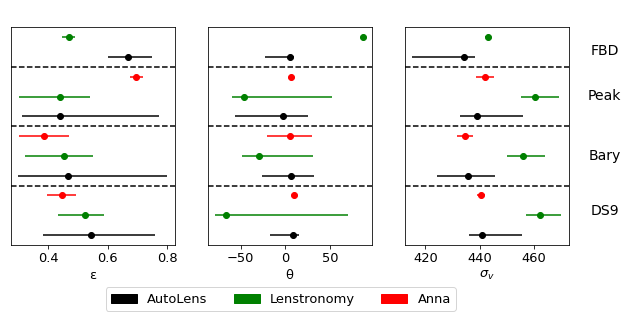

In [9]:
plt.rcParams.update({"font.size": 13})

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

for i in range(0, len(names)):
    for j in range(0, len(mega_dataframe)):
        if j==2 or j==5 or j==8:
            ax[i].errorbar(mega_dataframe[j]['value'][i], j, xerr=np.array([[mega_dataframe[j]['err'][i]], [mega_dataframe[j]['err'][i]]]), fmt="o", c=colors[j])
            ax[i].axhline(y=j+0.5, color='k', linestyle='--')
        else:
            lower, mean, upper = np.percentile(mega_dataframe[j][names[i]][int(float(len(mega_dataframe[j])*burnins[j])):], [15.85, 50., 84.05])
            ax[i].errorbar(mean, j, xerr=np.array([[mean-lower], [upper-mean]]), fmt="o", c=colors[j])
        ax[i].set_yticks([])
        ax[i].set_xlabel(labels[i])

k_patch = mpatches.Patch(color='k', label='AutoLens')  
g_patch = mpatches.Patch(color='g', label='Lenstronomy')    
r_patch = mpatches.Patch(color='r', label='Anna')    

    
ax[2].annotate('DS9',
               xy=(0., 0.),
               xycoords=('axes fraction', 'figure fraction'),
               xytext=(200., 100.),
               textcoords='offset points',
               size=14, ha='center', va='bottom',
               rotation=0.)
ax[2].annotate('Bary',
               xy=(0., 0.),
               xycoords=('axes fraction', 'figure fraction'),
               xytext=(200., 155.),
               textcoords='offset points',
               size=14, ha='center', va='bottom',
               rotation=0.)
ax[2].annotate('Peak',
               xy=(0., 0.),
               xycoords=('axes fraction', 'figure fraction'),
               xytext=(200., 215.),
               textcoords='offset points',
               size=14, ha='center', va='bottom',
               rotation=0.)
ax[2].annotate('FBD',
               xy=(0., 0.),
               xycoords=('axes fraction', 'figure fraction'),
               xytext=(200., 260.),
               textcoords='offset points',
               size=14, ha='center', va='bottom',
               rotation=0.)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5, handles=[k_patch, g_patch, r_patch]);

In [10]:
def rel_deg_to_arcsec(img_x, img_y, origin):
    img_x = np.array(img_x)
    img_y = np.array(img_y)
    img_x = img_x - origin[0]
    img_y = img_y - origin[1]
    for i in range(0, len(img_x)):
        img_x[i] = (img_x[i]*u.deg).to(u.arcsec).value
        img_y[i] = (img_y[i]*u.deg).to(u.arcsec).value
        
    return img_x, img_y

In [11]:
# RMS analysis
reference_position = [24.163281, 0.13847326]
# point-source positions determined by Anna
ps_positions_x_ds9 = [24.163159, 24.162377, 24.162791, 24.163895]
ps_positions_y_ds9 = [0.13943114, 0.13793125, 0.13761556, 0.1381123]
ps_positions_x_ds9, ps_positions_y_ds9 = rel_deg_to_arcsec(ps_positions_x_ds9, ps_positions_y_ds9, reference_position)

ps_positions_x_bary = [24.163108, 24.162375, 24.162887, 24.163871]
ps_positions_y_bary = [0.13940833, 0.13794167, 0.13762222, 0.13808333]
ps_positions_x_bary, ps_positions_y_bary = rel_deg_to_arcsec(ps_positions_x_bary, ps_positions_y_bary, reference_position)

ps_positions_x_peak = [24.16319, 24.162364, 24.162829, 24.163914]
ps_positions_y_peak = [0.139424, 0.137977, 0.137615, 0.138132]
ps_positions_x_peak, ps_positions_y_peak = rel_deg_to_arcsec(ps_positions_x_peak, ps_positions_y_peak, reference_position)

# Anna obtained positions


In [12]:
# get lenstronomy positions

ps_positions_x_ds9_lenstronomy = [np.percentile(lenstronomy_ds9['ra_image'], 50), np.percentile(lenstronomy_ds9['ra_image.1'], 50), np.percentile(lenstronomy_ds9['ra_image.2'], 50), np.percentile(lenstronomy_ds9['ra_image.3'], 50)]
ps_positions_y_ds9_lenstronomy = [np.percentile(lenstronomy_ds9['dec_image'], 50), np.percentile(lenstronomy_ds9['dec_image.1'], 50), np.percentile(lenstronomy_ds9['dec_image.2'], 50), np.percentile(lenstronomy_ds9['dec_image.3'], 50)]

ps_positions_x_bary_lenstronomy = [np.percentile(lenstronomy_bary['ra_image'], 50), np.percentile(lenstronomy_bary['ra_image.1'], 50), np.percentile(lenstronomy_bary['ra_image.2'], 50), np.percentile(lenstronomy_bary['ra_image.3'], 50)]
ps_positions_y_bary_lenstronomy = [np.percentile(lenstronomy_bary['dec_image'], 50), np.percentile(lenstronomy_bary['dec_image.1'], 50), np.percentile(lenstronomy_bary['dec_image.2'], 50), np.percentile(lenstronomy_bary['dec_image.3'], 50)]

ps_positions_x_peak_lenstronomy = [np.percentile(lenstronomy_peak['ra_image'], 50), np.percentile(lenstronomy_peak['ra_image.1'], 50), np.percentile(lenstronomy_peak['ra_image.2'], 50), np.percentile(lenstronomy_peak['ra_image.3'], 50)]
ps_positions_y_peak_lenstronomy = [np.percentile(lenstronomy_peak['dec_image'], 50), np.percentile(lenstronomy_peak['dec_image.1'], 50), np.percentile(lenstronomy_peak['dec_image.2'], 50), np.percentile(lenstronomy_peak['dec_image.3'], 50)]

In [13]:
from sklearn.metrics import mean_squared_error

In [14]:
rmse_ds9 = mean_squared_error([ps_positions_x_ds9_lenstronomy, ps_positions_y_ds9_lenstronomy], [ps_positions_x_ds9, ps_positions_y_ds9])
rmse_bary = mean_squared_error([ps_positions_x_bary_lenstronomy, ps_positions_y_bary_lenstronomy], [ps_positions_x_bary, ps_positions_y_bary])
rmse_peak = mean_squared_error([ps_positions_x_peak_lenstronomy, ps_positions_y_peak_lenstronomy], [ps_positions_x_peak, ps_positions_y_peak])

In [15]:
ps_positions_x_peak

array([-0.3276, -3.3012, -1.6272,  2.2788])

In [16]:
ps_positions_y_peak

array([ 3.422664, -1.786536, -3.089736, -1.228536])

In [17]:
source_x = [24.1631900]
source_y = [0.1394240]

In [18]:
source_x

[24.16319]

In [19]:
 rel_deg_to_arcsec(source_x, source_y, reference_position)

(array([-0.3276]), array([3.422664]))

In [20]:
mean_squared_error([-0.4395517708206327, 3.448212863362563], [-0.4392, 3.448368])

7.390504326190483e-08

In [21]:
ps_positions_y_ds9

array([ 3.448368, -1.951236, -3.08772 , -1.299456])

In [22]:
(-0.4395517708206327+0.4392)+(3.448212863362563-3.448368)

-0.0005069074580695276